# **Phase 1: Data Preparation & Exploration (การเตรียมและสำรวจข้อมูล)**

Import Libraries

In [25]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.model_selection import RandomizedSearchCV

sns.set_theme(style="whitegrid")
pd.options.mode.chained_assignment = None

In [3]:
from google.colab import drive
drive.mount('/content/drive') #ถ้าไม่มีการเชื่อมต่อ Google Drive ข้ามขั้นตอนนี้ได้เลยค่ะ

Mounted at /content/drive


Load Data & เช็คภาพรวม

In [4]:
df = pd.read_csv('/content/drive/MyDrive/Project_Datasci/train 2.csv') #เปลี่ยน path เป็น path ของคุณเองก่อนใช้งานค่ะ

print("First 5 Rows")
display(df.head())

print("\nData Information")
df.info()

print("\nStatistical Summary")
display(df.describe())

First 5 Rows


,id,log_price,property_type,room_type,amenities,accommodates,bathrooms,bed_type,cancellation_policy,cleaning_fee,...,latitude,longitude,name,neighbourhood,number_of_reviews,review_scores_rating,thumbnail_url,zipcode,bedrooms,beds
0,6901257,5.010635,Apartment,Entire home/apt,"{""Wireless Internet"",""Air conditioning"",Kitche...",3,1.0,Real Bed,strict,True,...,40.696524,-73.991617,Beautiful brownstone 1-bedroom,Brooklyn Heights,2,100.0,https://a0.muscache.com/im/pictures/6d7cbbf7-c...,11201,1.0,1.0
1,6304928,5.129899,Apartment,Entire home/apt,"{""Wireless Internet"",""Air conditioning"",Kitche...",7,1.0,Real Bed,strict,True,...,40.766115,-73.989040,Superb 3BR Apt Located Near Times Square,Hell's Kitchen,6,93.0,https://a0.muscache.com/im/pictures/348a55fe-4...,10019,3.0,3.0
2,7919400,4.976734,Apartment,Entire home/apt,"{TV,""Cable TV"",""Wireless Internet"",""Air condit...",5,1.0,Real Bed,moderate,True,...,40.808110,-73.943756,The Garden Oasis,Harlem,10,92.0,https://a0.muscache.com/im/pictures/6fae5362-9...,10027,1.0,3.0
3,13418779,6.620073,House,Entire home/apt,"{TV,""Cable TV"",Internet,""Wireless Internet"",Ki...",4,1.0,Real Bed,flexible,True,...,37.772004,-122.431619,Beautiful Flat in the Heart of SF!,Lower Haight,0,NaN,https://a0.muscache.com/im/pictures/72208dad-9...,94117.0,2.0,2.0
4,3808709,4.744932,Apartment,Entire home/apt,"{TV,Internet,""Wireless Internet"",""Air conditio...",2,1.0,Real Bed,moderate,True,...,38.925627,-77.034596,Great studio in midtown DC,Columbia Heights,4,40.0,NaN,20009,0.0,1.0



Data Information
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 74111 entries, 0 to 74110
Data columns (total 29 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   id                      74111 non-null  int64  
 1   log_price               74111 non-null  float64
 2   property_type           74111 non-null  object 
 3   room_type               74111 non-null  object 
 4   amenities               74111 non-null  object 
 5   accommodates            74111 non-null  int64  
 6   bathrooms               73911 non-null  float64
 7   bed_type                74111 non-null  object 
 8   cancellation_policy     74111 non-null  object 
 9   cleaning_fee            74111 non-null  bool   
 10  city                    74111 non-null  object 
 11  description             74111 non-null  object 
 12  first_review            58247 non-null  object 
 13  host_has_profile_pic    73923 non-null  object 
 14  host_identity_verifi

,id,log_price,accommodates,bathrooms,latitude,longitude,number_of_reviews,review_scores_rating,bedrooms,beds
count,7.411100e+04,74111.000000,74111.000000,73911.000000,74111.000000,74111.000000,74111.000000,57389.000000,74020.000000,73980.000000
mean,1.126662e+07,4.782069,3.155146,1.235263,38.445958,-92.397525,20.900568,94.067365,1.265793,1.710868
std,6.081735e+06,0.717394,2.153589,0.582044,3.080167,21.705322,37.828641,7.836556,0.852143,1.254142
min,3.440000e+02,0.000000,1.000000,0.000000,33.338905,-122.511500,0.000000,20.000000,0.000000,0.000000
25%,6.261964e+06,4.317488,2.000000,1.000000,34.127908,-118.342374,1.000000,92.000000,1.000000,1.000000
50%,1.225415e+07,4.709530,2.000000,1.000000,40.662138,-76.996965,6.000000,96.000000,1.000000,1.000000
75%,1.640226e+07,5.220356,4.000000,1.000000,40.746096,-73.954660,23.000000,100.000000,1.000000,2.000000
max,2.123090e+07,7.600402,16.000000,8.000000,42.390437,-70.985047,605.000000,100.000000,10.000000,18.000000


เช็คค่าว่าง (Missing Values)

In [5]:
missing_data = df.isnull().sum()
missing_percent = (df.isnull().sum() / len(df)) * 100

missing_df = pd.DataFrame({'Missing Values': missing_data, 'Percentage (%)': missing_percent})
display(missing_df[missing_df['Missing Values'] > 0].sort_values(by='Percentage (%)', ascending=False))

,Missing Values,Percentage (%)
host_response_rate,18299,24.691341
review_scores_rating,16722,22.563452
first_review,15864,21.405729
last_review,15827,21.355804
thumbnail_url,8216,11.086074
neighbourhood,6872,9.272578
zipcode,966,1.303450
bathrooms,200,0.269865
host_has_profile_pic,188,0.253674
host_identity_verified,188,0.253674


ดูการกระจายตัวของตัวแปรเป้าหมาย (Target Variable)

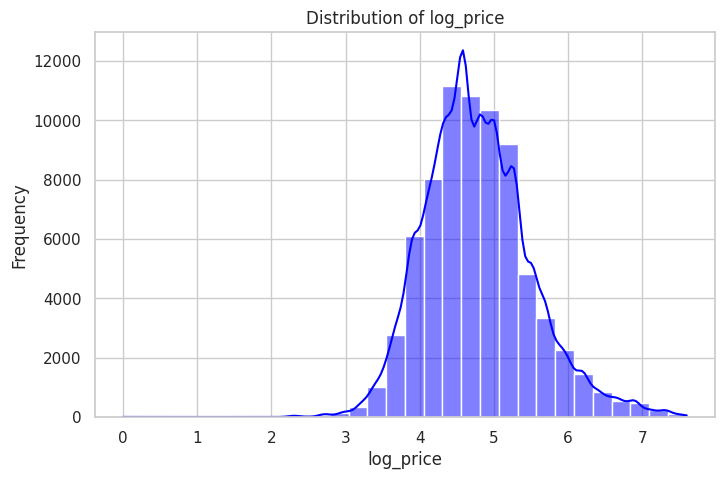

In [6]:
target_col = 'log_price'

plt.figure(figsize=(8, 5))
sns.histplot(df[target_col], kde=True, bins=30, color='blue')
plt.title(f'Distribution of {target_col}')
plt.xlabel(target_col)
plt.ylabel('Frequency')
plt.show()

ดูความสัมพันธ์ระหว่างตัวแปร (Correlation Matrix)

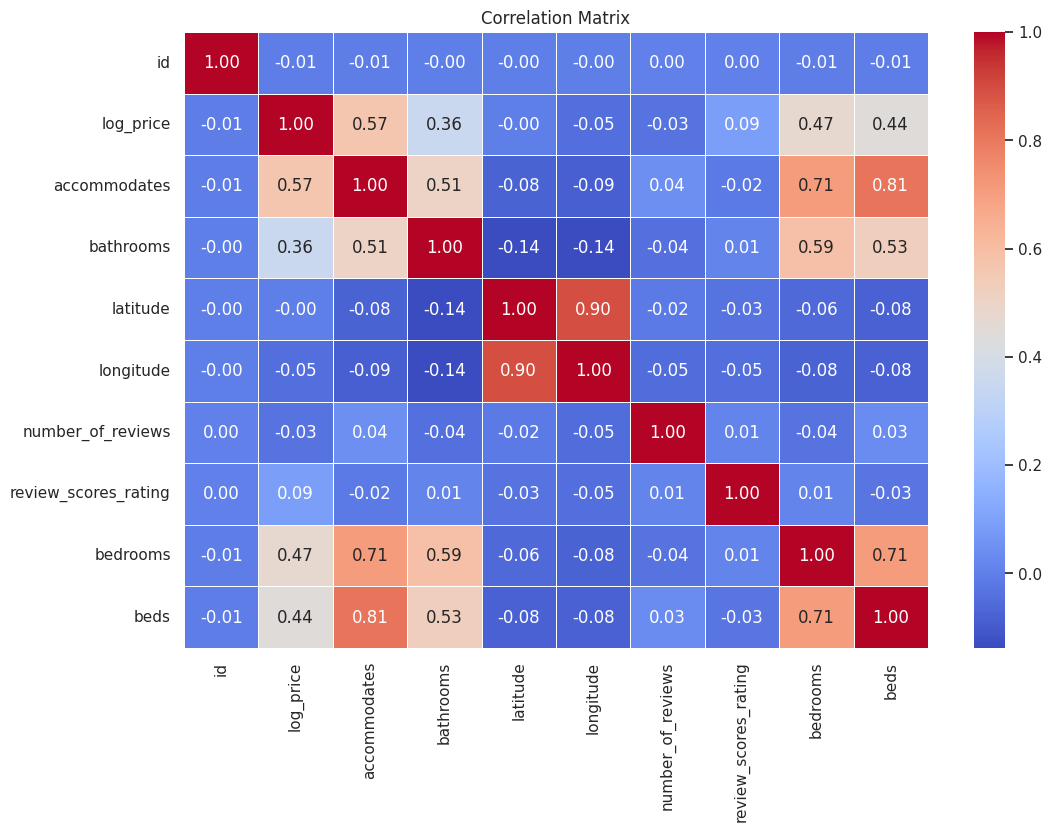

In [7]:
plt.figure(figsize=(12, 8))

numeric_cols = df.select_dtypes(include=[np.number])
correlation_matrix = numeric_cols.corr()

sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Correlation Matrix')
plt.show()

ลบคอลัมน์ที่ไม่จำเป็น และกรอง Target ที่ผิดปกติ

In [8]:
df_clean = df[df['log_price'] > 0].copy()

cols_to_drop = [
    'id', 'name', 'description', 'thumbnail_url',
    'amenities',
    'first_review', 'last_review', 'host_since',
    'host_response_rate', 'neighbourhood', 'zipcode'
]

df_clean = df_clean.drop(columns=cols_to_drop)

print(f"ขนาดข้อมูลหลังลบคอลัมน์และแถวที่ผิดปกติ: {df_clean.shape}")

ขนาดข้อมูลหลังลบคอลัมน์และแถวที่ผิดปกติ: (74110, 18)


จัดการค่าว่าง (Handling Missing Values)

In [9]:
numeric_cols_with_na = ['review_scores_rating', 'bathrooms', 'bedrooms', 'beds']
for col in numeric_cols_with_na:
    median_value = df_clean[col].median()
    df_clean[col] = df_clean[col].fillna(median_value)

categorical_cols_with_na = ['host_has_profile_pic', 'host_identity_verified']
df_clean = df_clean.dropna(subset=categorical_cols_with_na)

print(f"จำนวนค่าว่างที่เหลืออยู่ทั้งหมด: {df_clean.isnull().sum().max()}")

จำนวนค่าว่างที่เหลืออยู่ทั้งหมด: 0


# **Phase 2: Feature Engineering & Preprocessing (การปรุงแต่งข้อมูล)**

สำรวจ Outlier ด้วยตาเปล่า (Investigate Outliers)

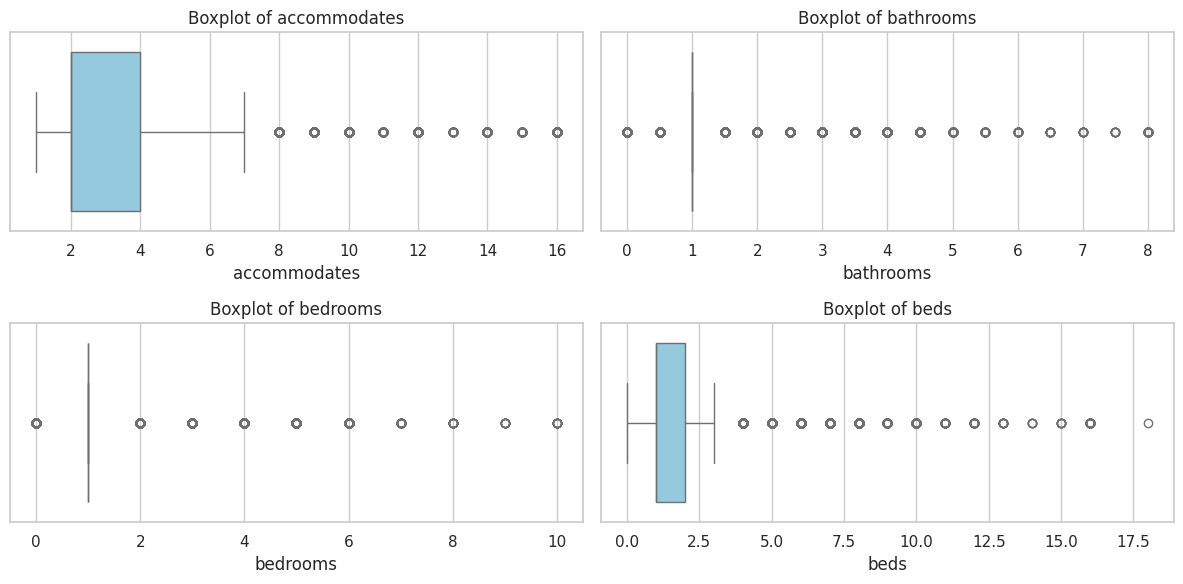


บ้านที่มีห้องนอนเยอะที่สุด 10 อันดับแรก


,log_price,property_type,accommodates,bathrooms,bedrooms,beds
32429,7.207860,House,16,4.0,10.0,13.0
17806,6.856462,Apartment,16,8.0,10.0,16.0
33147,7.170120,House,16,7.0,10.0,16.0
54697,7.495542,House,16,8.0,10.0,16.0
25562,6.212606,House,16,6.0,10.0,13.0
62442,6.257668,House,16,4.0,10.0,16.0
68070,6.388561,House,16,7.0,10.0,16.0
19213,6.684612,House,16,8.0,10.0,16.0
20098,5.700444,House,16,5.0,10.0,16.0
31193,4.828314,Townhouse,2,1.0,10.0,1.0


In [10]:
#Boxplot
features_to_check = ['accommodates', 'bathrooms', 'bedrooms', 'beds']

plt.figure(figsize=(12, 6))
for i, col in enumerate(features_to_check, 1):
    plt.subplot(2, 2, i)
    sns.boxplot(x=df_clean[col], color='skyblue')
    plt.title(f'Boxplot of {col}')
plt.tight_layout()
plt.show()

print("\nบ้านที่มีห้องนอนเยอะที่สุด 10 อันดับแรก")
display(df_clean[['log_price', 'property_type', 'accommodates', 'bathrooms', 'bedrooms', 'beds']].sort_values(by='bedrooms', ascending=False).head(10))

จัดการ Outlier แบบมีเหตุผล (Logical Filtering)

In [11]:
illogical_condition = (
    ((df_clean['bedrooms'] > 5) & (df_clean['accommodates'] <= 2)) |
    (df_clean['bedrooms'] > df_clean['accommodates']) |
    (df_clean['bathrooms'] > (df_clean['accommodates'] + 1))
)

df_clean = df_clean[~illogical_condition]

print(f"ขนาดข้อมูลหลังกำจัด Logical Outliers: {df_clean.shape}")

ขนาดข้อมูลหลังกำจัด Logical Outliers: (73422, 18)


ตรวจสอบ Boxplot หลังจัดการ Logical Outlier

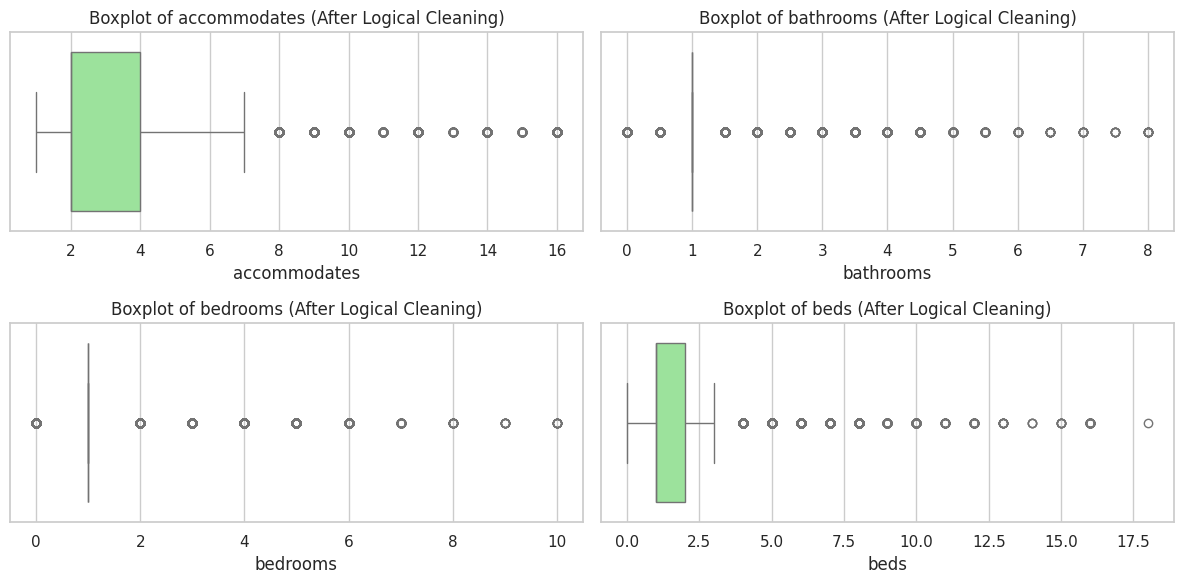


บ้านที่มีห้องนอนเยอะที่สุด 10 อันดับแรก


,log_price,property_type,accommodates,bathrooms,bedrooms,beds
54697,7.495542,House,16,8.0,10.0,16.0
25562,6.212606,House,16,6.0,10.0,13.0
17806,6.856462,Apartment,16,8.0,10.0,16.0
68070,6.388561,House,16,7.0,10.0,16.0
20098,5.700444,House,16,5.0,10.0,16.0
62442,6.257668,House,16,4.0,10.0,16.0
32429,7.207860,House,16,4.0,10.0,13.0
33147,7.170120,House,16,7.0,10.0,16.0
19213,6.684612,House,16,8.0,10.0,16.0
17478,6.445720,Apartment,16,6.0,9.0,16.0


In [12]:
features_to_check = ['accommodates', 'bathrooms', 'bedrooms', 'beds']

plt.figure(figsize=(12, 6))
for i, col in enumerate(features_to_check, 1):
    plt.subplot(2, 2, i)
    sns.boxplot(x=df_clean[col], color='lightgreen')
    plt.title(f'Boxplot of {col} (After Logical Cleaning)')
plt.tight_layout()
plt.show()

print("\nบ้านที่มีห้องนอนเยอะที่สุด 10 อันดับแรก")
display(df_clean[['log_price', 'property_type', 'accommodates', 'bathrooms', 'bedrooms', 'beds']].sort_values(by='bedrooms', ascending=False).head(10))

การเข้ารหัสข้อมูล (Feature Encoding)

In [13]:
bool_cols = ['cleaning_fee', 'host_has_profile_pic', 'host_identity_verified', 'instant_bookable']

for col in bool_cols:
    df_clean[col] = df_clean[col].replace({'t': 1, 'f': 0, True: 1, False: 0}).astype(int)

categorical_features = ['property_type', 'room_type', 'bed_type', 'cancellation_policy', 'city']
df_encoded = pd.get_dummies(df_clean, columns=categorical_features, drop_first=True)

print("Data Shape after Encoding")
print(f"จำนวนแถวและคอลัมน์ปัจจุบัน: {df_encoded.shape}")

print("\nData Types:")
print(df_encoded.dtypes.value_counts())

display(df_encoded.head(3))

/tmp/ipykernel_179/2296609853.py:4: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_clean[col] = df_clean[col].replace({'t': 1, 'f': 0, True: 1, False: 0}).astype(int)
/tmp/ipykernel_179/2296609853.py:4: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_clean[col] = df_clean[col].replace({'t': 1, 'f': 0, True: 1, False: 0}).astype(int)
/tmp/ipykernel_179/2296609853.py:4: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_

Data Shape after Encoding
จำนวนแถวและคอลัมน์ปัจจุบัน: (73422, 62)

Data Types:
bool       49
float64     7
int64       6
Name: count, dtype: int64


,log_price,accommodates,bathrooms,cleaning_fee,host_has_profile_pic,host_identity_verified,instant_bookable,latitude,longitude,number_of_reviews,...,bed_type_Real Bed,cancellation_policy_moderate,cancellation_policy_strict,cancellation_policy_super_strict_30,cancellation_policy_super_strict_60,city_Chicago,city_DC,city_LA,city_NYC,city_SF
0,5.010635,3,1.0,1,1,1,0,40.696524,-73.991617,2,...,True,False,True,False,False,False,False,False,True,False
1,5.129899,7,1.0,1,1,0,1,40.766115,-73.989040,6,...,True,False,True,False,False,False,False,False,True,False
2,4.976734,5,1.0,1,1,1,1,40.808110,-73.943756,10,...,True,True,False,False,False,False,False,False,True,False


แปลง True/False ให้เป็น 1/0

In [14]:
bool_columns = df_encoded.select_dtypes(include='bool').columns
df_encoded[bool_columns] = df_encoded[bool_columns].astype(int)

print("อัปเดต Data Types")
print(df_encoded.dtypes.value_counts())

อัปเดต Data Types
int64      55
float64     7
Name: count, dtype: int64


การแบ่งข้อมูล (Train/Test Split)

In [15]:
X = df_encoded.drop('log_price', axis=1)
y = df_encoded['log_price']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"ขนาดของข้อมูลสำหรับสอน (X_train): {X_train.shape}")
print(f"ขนาดของข้อมูลสำหรับสอบ (X_test): {X_test.shape}")

ขนาดของข้อมูลสำหรับสอน (X_train): (58737, 61)
ขนาดของข้อมูลสำหรับสอบ (X_test): (14685, 61)


การปรับสเกลข้อมูล (Feature Scaling)

ทำไมต้องทำ? เพราะโมเดล Regression มักจะให้ความสำคัญกับคอลัมน์ที่มีค่าตัวเลขสูงๆ (เช่น number_of_reviews อาจจะมีหลักร้อย) มากกว่าคอลัมน์ที่มีค่าน้อยๆ (เช่น bathrooms มีแค่ 1-10) เราจึงต้องบีบตัวเลขทุกคอลัมน์ให้อยู่ในสเกลมาตรฐานเดียวกันด้วย StandardScaler

⚠️ กฎเหล็ก: ต้องเรียนรู้ค่าสถิติ (Mean, SD) จาก Train set เท่านั้น แล้วค่อยเอาไปประยุกต์ใช้กับ Test set ห้ามเอา Test set มาร่วมคำนวณเด็ดขาด เพื่อป้องกันการโกงข้อสอบ (Data Leakage)

In [16]:
scaler = StandardScaler()

numeric_features = [
    'accommodates', 'bathrooms', 'bedrooms', 'beds',
    'latitude', 'longitude', 'number_of_reviews', 'review_scores_rating'
]

X_train_scaled = X_train.copy()
X_train_scaled[numeric_features] = scaler.fit_transform(X_train[numeric_features])

X_test_scaled = X_test.copy()
X_test_scaled[numeric_features] = scaler.transform(X_test[numeric_features])

print("Data Shape & Sample after Scaling")
print("สเกลข้อมูลเรียบร้อยแล้ว!")
display(X_train_scaled[numeric_features].head(3))

Data Shape & Sample after Scaling
สเกลข้อมูลเรียบร้อยแล้ว!


,accommodates,bathrooms,bedrooms,beds,latitude,longitude,number_of_reviews,review_scores_rating
61265,-0.540492,-0.407328,-0.305386,-0.569792,0.753173,0.858988,-0.475080,-0.214968
26705,-1.004947,-0.407328,-0.305386,-0.569792,0.772965,0.852967,-0.554035,0.215890
56519,1.317327,0.502481,3.245646,1.849630,-0.228999,-1.380568,1.761998,0.072271


# **Phase 3: Model Training & Tuning (การฝึกสอนและจูนสมองกล)**

Linear Regression

ผลการประเมินโมเดล Linear Regression
MAE: 0.3502
RMSE: 0.4697
R-squared: 0.5818


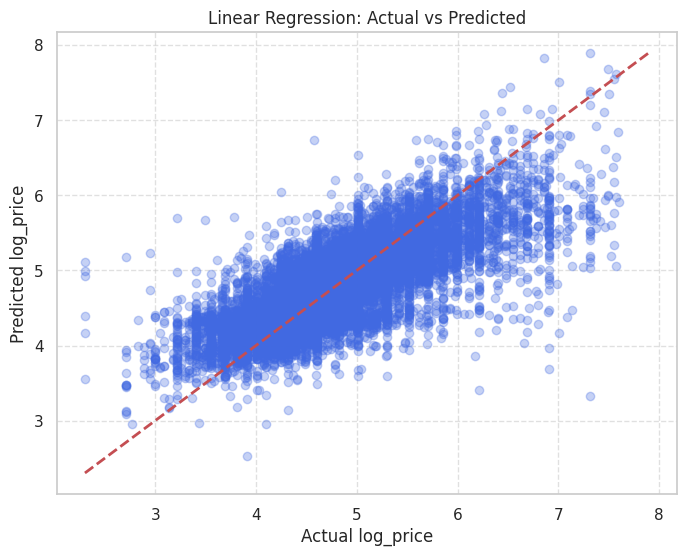

In [17]:
lr_model = LinearRegression()

lr_model.fit(X_train_scaled, y_train)

y_pred_lr = lr_model.predict(X_test_scaled)

mae = mean_absolute_error(y_test, y_pred_lr)
rmse = np.sqrt(mean_squared_error(y_test, y_pred_lr))
r2 = r2_score(y_test, y_pred_lr)

print("ผลการประเมินโมเดล Linear Regression")
print(f"MAE: {mae:.4f}")
print(f"RMSE: {rmse:.4f}")
print(f"R-squared: {r2:.4f}")

plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred_lr, alpha=0.3, color='royalblue')

min_val = min(y_test.min(), y_pred_lr.min())
max_val = max(y_test.max(), y_pred_lr.max())
plt.plot([min_val, max_val], [min_val, max_val], 'r--', lw=2)

plt.xlabel('Actual log_price')
plt.ylabel('Predicted log_price')
plt.title('Linear Regression: Actual vs Predicted')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

Random Forest Model

กำลังเทรนโมเดล Random Forest... รอสักครู่นะคะ ⏳

ผลการประเมินโมเดล Random Forest
MAE  : 0.2871
RMSE : 0.4014
R-squared: 0.6946


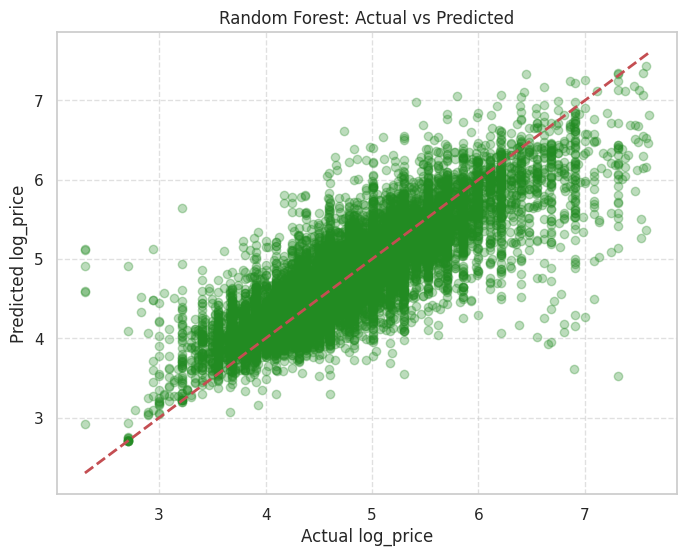

In [18]:
rf_model = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)

print("กำลังเทรนโมเดล Random Forest... รอสักครู่นะคะ ⏳")
rf_model.fit(X_train_scaled, y_train)

y_pred_rf = rf_model.predict(X_test_scaled)

mae_rf = mean_absolute_error(y_test, y_pred_rf)
rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))
r2_rf = r2_score(y_test, y_pred_rf)

print("\nผลการประเมินโมเดล Random Forest")
print(f"MAE  : {mae_rf:.4f}")
print(f"RMSE : {rmse_rf:.4f}")
print(f"R-squared: {r2_rf:.4f}")

plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred_rf, alpha=0.3, color='forestgreen')
min_val = min(y_test.min(), y_pred_rf.min())
max_val = max(y_test.max(), y_pred_rf.max())
plt.plot([min_val, max_val], [min_val, max_val], 'r--', lw=2)

plt.xlabel('Actual log_price')
plt.ylabel('Predicted log_price')
plt.title('Random Forest: Actual vs Predicted')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

XGBoost

กำลังเทรนโมเดล XGBoost... 🚀

ผลการประเมินโมเดล XGBoost
MAE: 0.2883
RMSE: 0.3967
R-squared: 0.7018


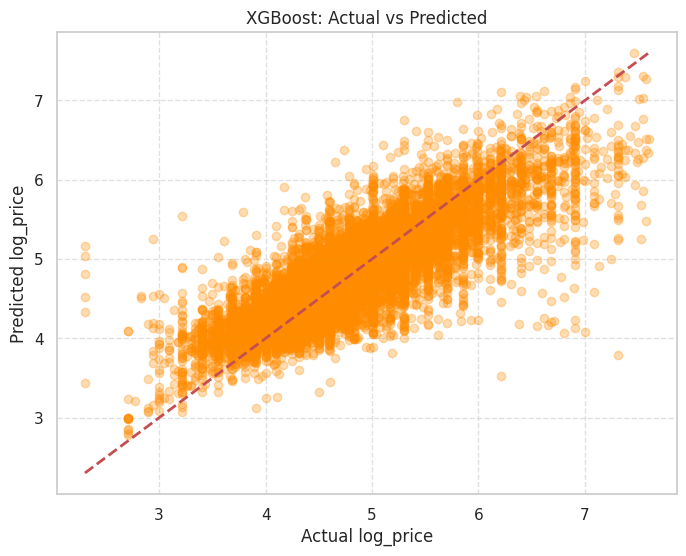

In [19]:
xgb_model = XGBRegressor(n_estimators=100, learning_rate=0.1, random_state=42, n_jobs=-1)

print("กำลังเทรนโมเดล XGBoost... 🚀")
xgb_model.fit(X_train_scaled, y_train)

y_pred_xgb = xgb_model.predict(X_test_scaled)

mae_xgb = mean_absolute_error(y_test, y_pred_xgb)
rmse_xgb = np.sqrt(mean_squared_error(y_test, y_pred_xgb))
r2_xgb = r2_score(y_test, y_pred_xgb)

print("\nผลการประเมินโมเดล XGBoost")
print(f"MAE: {mae_xgb:.4f}")
print(f"RMSE: {rmse_xgb:.4f}")
print(f"R-squared: {r2_xgb:.4f}")

plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred_xgb, alpha=0.3, color='darkorange')

min_val = min(y_test.min(), y_pred_xgb.min())
max_val = max(y_test.max(), y_pred_xgb.max())
plt.plot([min_val, max_val], [min_val, max_val], 'r--', lw=2)

plt.xlabel('Actual log_price')
plt.ylabel('Predicted log_price')
plt.title('XGBoost: Actual vs Predicted')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

LightGBM

กำลังเทรนโมเดล LightGBM... ⚡
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.012161 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 949
[LightGBM] [Info] Number of data points in the train set: 58737, number of used features: 44
[LightGBM] [Info] Start training from score 4.783207

ผลการประเมินโมเดล LightGBM
MAE: 0.2864
RMSE: 0.3947
R-squared: 0.7048


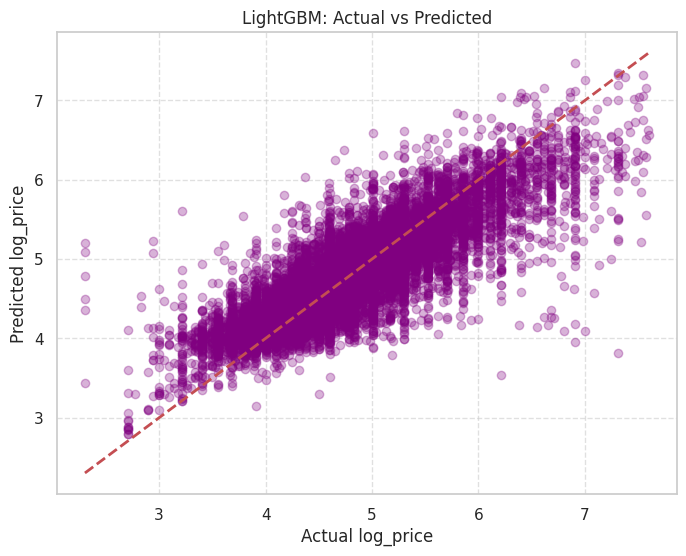

In [20]:
lgbm_model = LGBMRegressor(n_estimators=100, random_state=42, n_jobs=-1)

print("กำลังเทรนโมเดล LightGBM... ⚡")
lgbm_model.fit(X_train_scaled, y_train)

y_pred_lgbm = lgbm_model.predict(X_test_scaled)

mae_lgbm = mean_absolute_error(y_test, y_pred_lgbm)
rmse_lgbm = np.sqrt(mean_squared_error(y_test, y_pred_lgbm))
r2_lgbm = r2_score(y_test, y_pred_lgbm)

print("\nผลการประเมินโมเดล LightGBM")
print(f"MAE: {mae_lgbm:.4f}")
print(f"RMSE: {rmse_lgbm:.4f}")
print(f"R-squared: {r2_lgbm:.4f}")

plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred_lgbm, alpha=0.3, color='purple')
min_val = min(y_test.min(), y_pred_lgbm.min())
max_val = max(y_test.max(), y_pred_lgbm.max())
plt.plot([min_val, max_val], [min_val, max_val], 'r--', lw=2)

plt.xlabel('Actual log_price')
plt.ylabel('Predicted log_price')
plt.title('LightGBM: Actual vs Predicted')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

KNN

กำลังเทรนโมเดล KNN... 🔍

ผลการประเมินโมเดล KNN
MAE  : 0.3580
RMSE : 0.4788
R-squared: 0.5655


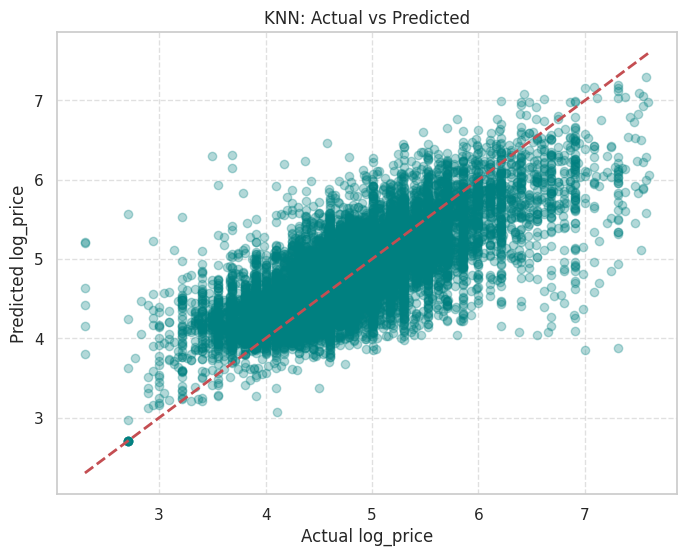

In [21]:
knn_model = KNeighborsRegressor(n_neighbors=9, n_jobs=-1)

print("กำลังเทรนโมเดล KNN... 🔍")
knn_model.fit(X_train_scaled, y_train)

y_pred_knn = knn_model.predict(X_test_scaled)

mae_knn = mean_absolute_error(y_test, y_pred_knn)
rmse_knn = np.sqrt(mean_squared_error(y_test, y_pred_knn))
r2_knn = r2_score(y_test, y_pred_knn)

print("\nผลการประเมินโมเดล KNN")
print(f"MAE  : {mae_knn:.4f}")
print(f"RMSE : {rmse_knn:.4f}")
print(f"R-squared: {r2_knn:.4f}")

plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred_knn, alpha=0.3, color='teal')

min_val = min(y_test.min(), y_pred_knn.min())
max_val = max(y_test.max(), y_pred_knn.max())
plt.plot([min_val, max_val], [min_val, max_val], 'r--', lw=2)

plt.xlabel('Actual log_price')
plt.ylabel('Predicted log_price')
plt.title('KNN: Actual vs Predicted')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

# **Phase 5: การเปรียบเทียบและการอธิบายโมเดล (Evaluation & Interpretation)**

Grand Leaderboard (จัดอันดับ 5 โมเดล)

🏆 ตารางเปรียบเทียบประสิทธิภาพโมเดล (Grand Leaderboard) 🏆


,Model,MAE,RMSE,R-squared
0,LightGBM,0.286392,0.394657,0.704784
1,XGBoost,0.288342,0.396666,0.701771
2,Random Forest,0.287107,0.401375,0.694648
3,Linear Regression,0.350155,0.469723,0.581800
4,KNN,0.357984,0.478767,0.565541


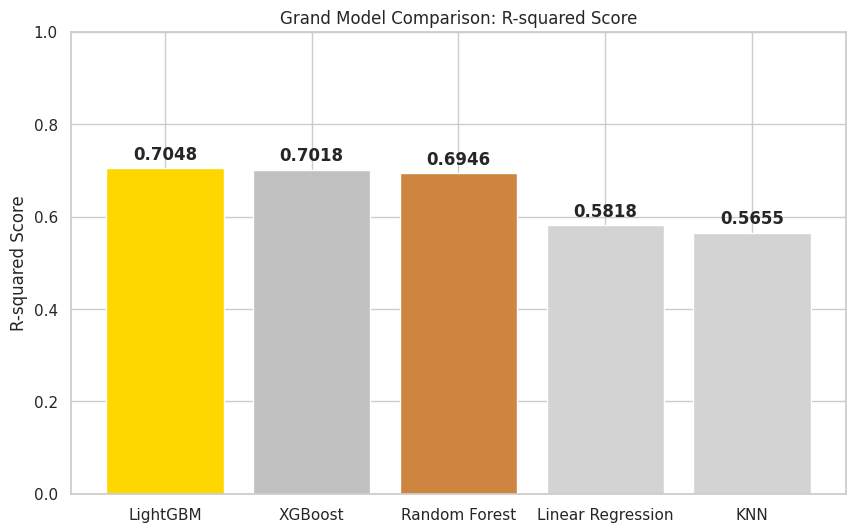

In [22]:
model_comparison = pd.DataFrame({
    'Model': ['Linear Regression', 'Random Forest', 'XGBoost', 'LightGBM', 'KNN'],
    'MAE': [mae, mae_rf, mae_xgb, mae_lgbm, mae_knn],
    'RMSE': [rmse, rmse_rf, rmse_xgb, rmse_lgbm, rmse_knn],
    'R-squared': [r2, r2_rf, r2_xgb, r2_lgbm, r2_knn]
})

leaderboard = model_comparison.sort_values(by='R-squared', ascending=False).reset_index(drop=True)

print("🏆 ตารางเปรียบเทียบประสิทธิภาพโมเดล (Grand Leaderboard) 🏆")
display(leaderboard)

plt.figure(figsize=(10, 6))
colors = ['gold' if i == 0 else 'silver' if i == 1 else 'peru' if i == 2 else 'lightgray' for i in range(len(leaderboard))]
bars = plt.bar(leaderboard['Model'], leaderboard['R-squared'], color=colors)

for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 0.01, f'{yval:.4f}', ha='center', va='bottom', fontweight='bold')

plt.ylabel('R-squared Score')
plt.title('Grand Model Comparison: R-squared Score')
plt.ylim(0, 1.0)
plt.show()

🧠 ส่องสมองแชมป์เปี้ยน (Feature Importance ของ LightGBM)


15 อันดับตัวแปรที่ส่งผลต่อการตัดสินใจของ LightGBM มากที่สุด


,Feature,Importance
7,longitude,825
6,latitude,774
8,number_of_reviews,234
0,accommodates,181
1,bathrooms,122
9,review_scores_rating,110
10,bedrooms,99
47,room_type_Shared room,79
2,cleaning_fee,56
46,room_type_Private room,55


/tmp/ipykernel_179/1004820700.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=top_15_features, palette='magma')


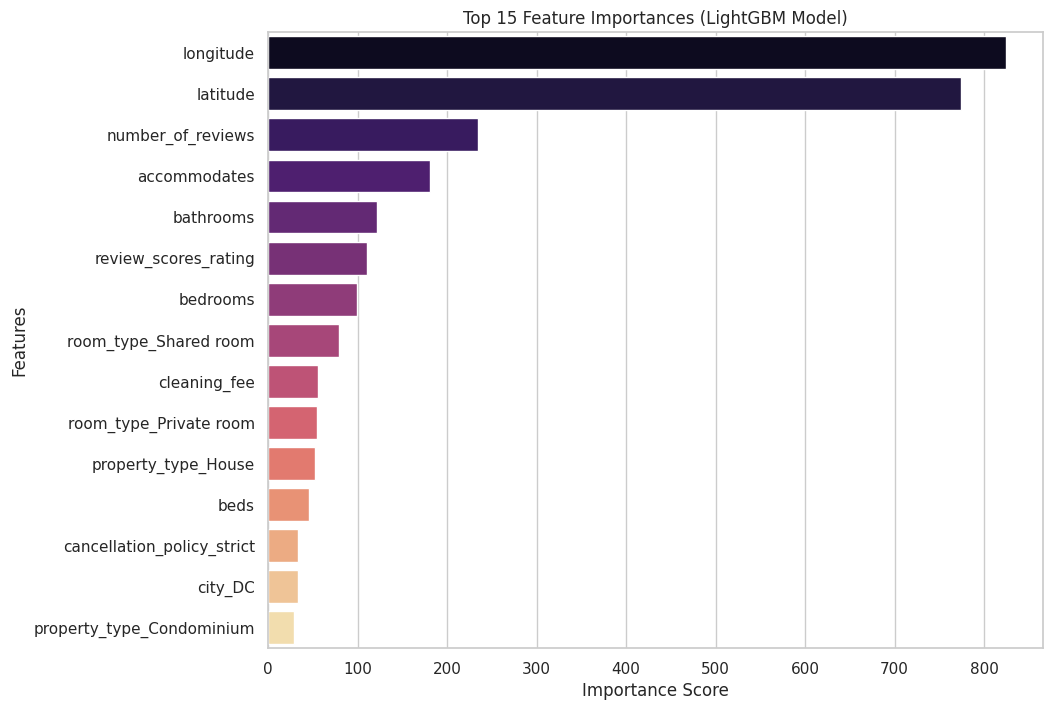

In [23]:
feature_importances = lgbm_model.feature_importances_

importance_df = pd.DataFrame({
    'Feature': X_train_scaled.columns,
    'Importance': feature_importances
})

top_15_features = importance_df.sort_values(by='Importance', ascending=False).head(15)

print("\n15 อันดับตัวแปรที่ส่งผลต่อการตัดสินใจของ LightGBM มากที่สุด")
display(top_15_features)

plt.figure(figsize=(10, 8))
sns.barplot(x='Importance', y='Feature', data=top_15_features, palette='magma')
plt.title('Top 15 Feature Importances (LightGBM Model)')
plt.xlabel('Importance Score')
plt.ylabel('Features')
plt.show()

จูนพารามิเตอร์ของโมเดล LightGBM (พร้อมทำ Cross-Validation)

In [24]:
from sklearn.model_selection import RandomizedSearchCV
from lightgbm import LGBMRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

param_grid = {
    'n_estimators': [100, 300, 500, 800],
    'learning_rate': [0.01, 0.05, 0.1, 0.2],
    'num_leaves': [31, 63, 127],
    'max_depth': [-1, 10, 15, 20],
    'subsample': [0.8, 0.9, 1.0]
}

lgbm_base = LGBMRegressor(random_state=42, n_jobs=-1)

random_search = RandomizedSearchCV(
    estimator=lgbm_base,
    param_distributions=param_grid,
    n_iter=20,
    cv=5,
    scoring='r2',
    random_state=42,
    n_jobs=-1,
    verbose=1
)

print("กำลังจูนโมเดล LightGBM พร้อมทำ 5-Fold CV... ⏳")
random_search.fit(X_train_scaled, y_train)

print("\n🎉 จูนเสร็จแล้ว! นี่คือการตั้งค่าที่ดีที่สุด (Best Parameters):")
print(random_search.best_params_)

best_lgbm = random_search.best_estimator_
y_pred_tuned = best_lgbm.predict(X_test_scaled)

mae_tuned = mean_absolute_error(y_test, y_pred_tuned)
rmse_tuned = np.sqrt(mean_squared_error(y_test, y_pred_tuned))
r2_tuned = r2_score(y_test, y_pred_tuned)

print("\n🏆 ผลการประเมิน LightGBM🏆")
print(f"MAE  : {mae_tuned:.4f}")
print(f"RMSE : {rmse_tuned:.4f}")
print(f"R-squared: {r2_tuned:.4f}")

กำลังจูนโมเดล LightGBM พร้อมทำ 5-Fold CV... ⏳
Fitting 5 folds for each of 20 candidates, totalling 100 fits
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.011299 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 949
[LightGBM] [Info] Number of data points in the train set: 58737, number of used features: 44
[LightGBM] [Info] Start training from score 4.783207

🎉 จูนเสร็จแล้ว! นี่คือการตั้งค่าที่ดีที่สุด (Best Parameters):
{'subsample': 1.0, 'num_leaves': 63, 'n_estimators': 500, 'max_depth': -1, 'learning_rate': 0.05}

🏆 ผลการประเมิน LightGBM🏆
MAE  : 0.2808
RMSE : 0.3895
R-squared: 0.7124


# **Phase 4: Exporting (การส่งออก)**

บันทึกโมเดลและตัวแปรที่จำเป็น (Model Saving)

In [35]:
#บันทึกโมเดลที่ดีที่สุด
joblib.dump(best_lgbm, 'airbnb_price_model.pkl')

#บันทึก Scaler
joblib.dump(scaler, 'data_scaler.pkl')

#บันทึกรายชื่อคอลัมน์ (Features) เพื่อกันสับสนตอนนำไปใช้ใน App
model_columns = list(X.columns)
joblib.dump(model_columns, 'model_columns.pkl')

print("✅ บันทึกโมเดลและไฟล์ที่เกี่ยวข้องเรียบร้อยแล้ว!")
print("ไฟล์ที่ได้: airbnb_price_model.pkl, data_scaler.pkl, model_columns.pkl")

✅ บันทึกโมเดลและไฟล์ที่เกี่ยวข้องเรียบร้อยแล้ว!
ไฟล์ที่ได้: airbnb_price_model.pkl, data_scaler.pkl, model_columns.pkl
